# Are Asset Returns Normal? Spoiler: They Are Not.

**Cordell Tanny, CFA, FRM, FDP**  
[ctanny.ca](https://ctanny.ca) | [github.com/ctanny](https://github.com/ctanny)

---

Most financial models assume asset returns follow a **normal distribution** — the classic bell curve. Mean-variance optimization, Value at Risk, Black-Scholes — they all rely on this assumption to some degree.

The problem? Asset returns are **not normal**. They never were.

Real returns have:
- **Fat tails** (leptokurtosis): extreme moves happen far more often than a normal distribution predicts
- **Skewness**: the distribution is often asymmetric — crashes tend to be sharper than rallies

This matters enormously when you are building risk models, sizing positions, running backtests, or stress testing a portfolio. If your model assumes normality and reality doesn't cooperate, your tail risk estimates are dangerously wrong.

In this notebook we will:
1. Download real ETF return data using `yfinance`
2. Compute key descriptive statistics (skewness and excess kurtosis)
3. Run two formal normality tests: **Jarque-Bera** and **Shapiro-Wilk**
4. Visualize the fat tails versus a normal distribution overlay

All data is from 2026-04-24.


## 1. Imports and Setup

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# Asset universe
tickers = {
    'SPY': 'US Equity',
    'TLT': 'Long Bonds',
    'GLD': 'Gold',
    'QQQ': 'Tech / Growth',
    'JNK': 'High Yield Bonds',
    'IBND' : 'International Bonds'
}

## 2. Download Price Data

We use `yfinance` to pull daily adjusted closing prices for each ETF going back to January 2010. We then compute **daily log returns**, which are more statistically tractable than simple returns for this kind of analysis.

In [6]:
raw = yf.download(
    list(tickers.keys()),
    start='2010-01-01',
    end='2026-04-24',
    auto_adjust=True,
    progress=False
)['Close']

# Daily log returns
returns = np.log(raw / raw.shift(1)).dropna()

print(f"Period : {returns.index[0].date()} to {returns.index[-1].date()}")
print(f"Observations: {len(returns)} trading days")
returns.head()

Period : 2010-05-21 to 2026-04-23
Observations: 4005 trading days


Ticker,GLD,IBND,JNK,QQQ,SPY,TLT
Date,,,,,,
2010-05-21,-0.005367,-0.000980,0.030813,0.010988,0.014493,0.001016
2010-05-24,0.013962,-0.012818,0.000000,-0.004022,-0.012914,-0.003461
2010-05-25,0.004441,-0.014327,-0.001865,0.000895,0.001021,0.004882
2010-05-26,0.009414,-0.006396,-0.017486,-0.011248,-0.006047,-0.002844
2010-05-27,0.001855,0.016080,0.018285,0.037086,0.032950,-0.022950


## 3. Descriptive Statistics

Before running formal tests, two statistics tell us a lot:

- **Skewness**: A normal distribution has skewness of 0. Negative skewness means the left tail (losses) is heavier — common in equity returns.
- **Excess kurtosis**: A normal distribution has excess kurtosis of 0. Positive excess kurtosis means fat tails — more extreme events than the normal distribution would predict. This is called **leptokurtosis**.

As a rule of thumb:
- Excess kurtosis > 1: noticeable fat tails
- Excess kurtosis > 3: severe fat tails

In [7]:
desc = pd.DataFrame({
    'Asset Class' : tickers,
    'Mean (daily)': returns.mean().round(6),
    'Std Dev'     : returns.std().round(6),
    'Skewness'    : returns.apply(stats.skew).round(3),
    'Excess Kurt' : returns.apply(stats.kurtosis).round(3),
})

print(desc.to_string())

              Asset Class  Mean (daily)   Std Dev  Skewness  Excess Kurt
GLD                  Gold      0.000328  0.010421    -0.713        7.357
IBND  International Bonds      0.000056  0.005860    -0.089        2.265
JNK      High Yield Bonds      0.000220  0.005151    -0.288       21.744
QQQ         Tech / Growth      0.000706  0.012996    -0.386        7.499
SPY             US Equity      0.000542  0.010810    -0.557       12.701
TLT            Long Bonds      0.000082  0.009472    -0.036        3.522


## 4. Formal Normality Tests

Descriptive statistics are suggestive, but we want formal statistical tests.

### Jarque-Bera Test
Tests whether skewness and kurtosis jointly match a normal distribution.  
- **H₀**: The data is normally distributed  
- **H₁**: The data is not normally distributed  
- A **p-value < 0.05** rejects normality

JB works well on large samples (which we have here).

### Shapiro-Wilk Test
Tests whether the data was drawn from a normal distribution.  
- Same hypothesis structure as JB  
- More sensitive on smaller samples  
- We run it on a 500-observation random sample for computational efficiency

> **Note**: Both tests are one-sided in the sense that rejection tells you the data is *not* normal — it does not tell you *what* distribution it follows. That is a separate question.

In [8]:
results = []

for ticker, label in tickers.items():
    r = returns[ticker].dropna()

    # Jarque-Bera
    jb_stat, jb_p = stats.jarque_bera(r)

    # Shapiro-Wilk on a random sample
    sample = r.sample(min(500, len(r)), random_state=42)
    sw_stat, sw_p = stats.shapiro(sample)

    results.append({
        'ETF'        : ticker,
        'Asset Class': label,
        'Skewness'   : round(stats.skew(r), 3),
        'Excess Kurt': round(stats.kurtosis(r), 3),
        'JB p-value' : round(jb_p, 6),
        'SW p-value' : round(sw_p, 6),
        'Normal?'    : 'No' if jb_p < 0.05 else 'Yes',
    })

df_results = pd.DataFrame(results).set_index('ETF')
print(df_results.to_string())
print("\np < 0.05 rejects the null hypothesis of normality")

              Asset Class  Skewness  Excess Kurt  JB p-value  SW p-value Normal?
ETF                                                                             
SPY             US Equity    -0.557       12.701         0.0    0.000000      No
TLT            Long Bonds    -0.036        3.522         0.0    0.000000      No
GLD                  Gold    -0.713        7.357         0.0    0.000000      No
QQQ         Tech / Growth    -0.386        7.499         0.0    0.000000      No
JNK      High Yield Bonds    -0.288       21.744         0.0    0.000000      No
IBND  International Bonds    -0.089        2.265         0.0    0.000004      No

p < 0.05 rejects the null hypothesis of normality


## Interpreting the Results

The results above tell a clear story. Not a single asset class passed either test.
Every p-value is effectively zero — normality is rejected across the board,
for both Jarque-Bera and Shapiro-Wilk.

### What the numbers mean

**Skewness**
All six assets show negative skewness. Returns are not symmetric.
The left tail (losses) is heavier than the right tail (gains).
Crashes tend to be sharper and faster than rallies. The data confirms it.

**Excess Kurtosis**
This is where it gets striking:

| ETF  | Excess Kurt | What it means |
|------|-------------|---------------|
| SPY  | 12.70 | Extreme fat tails. 2008, 2020, and similar crashes show up here. |
| TLT  | 3.52  | Moderate fat tails. Bond markets are calmer but still non-normal. |
| GLD  | 7.36  | Gold has significant fat tails despite its safe haven reputation. |
| QQQ  | 7.49  | Tech is volatile with frequent extreme moves in both directions. |
| JNK  | 21.75 | The most extreme result. High yield bonds seize up in a crisis. |
| IBND | 2.27  | The closest to normal — but still firmly rejects it. |

A normal distribution has excess kurtosis of 0.
Every asset here is well above that. JNK at 21.75 is not a typo.
High yield bonds behave relatively normally in calm markets and then
fall apart all at once in a crisis. That is exactly what excess kurtosis
of 21.75 looks like.

### Why this matters in practice

- **VaR models assuming normality will underestimate tail risk.**
  Significantly. A 99% VaR on SPY computed under normality ignores
  the reality of a distribution with excess kurtosis of 12.70.
- **Sharpe ratio assumes normality.** Use it, but treat it as one
  input, not the final word.
- **Backtests that simulate returns from a normal distribution
  are too optimistic.** Your strategy will look better in simulation
  than it performs in reality.

The fix is not to abandon these tools. It is to know their limits
and supplement them accordingly. Upcoming notebooks will cover
fat-tailed alternatives including Student-t distributions,
historical simulation, and GARCH volatility modeling.

## 5. Visualization: Actual Returns vs Normal Distribution

The chart below overlays a fitted normal distribution (orange curve) on top of the actual return histogram (blue bars) for each ETF.

What to look for:
- **Taller, narrower peak** than the normal curve = more observations near the mean
- **Wider, heavier tails** than the normal curve = more extreme events in reality

This pattern — tall center, fat tails — is called a **leptokurtic** distribution and is the hallmark of financial return data.

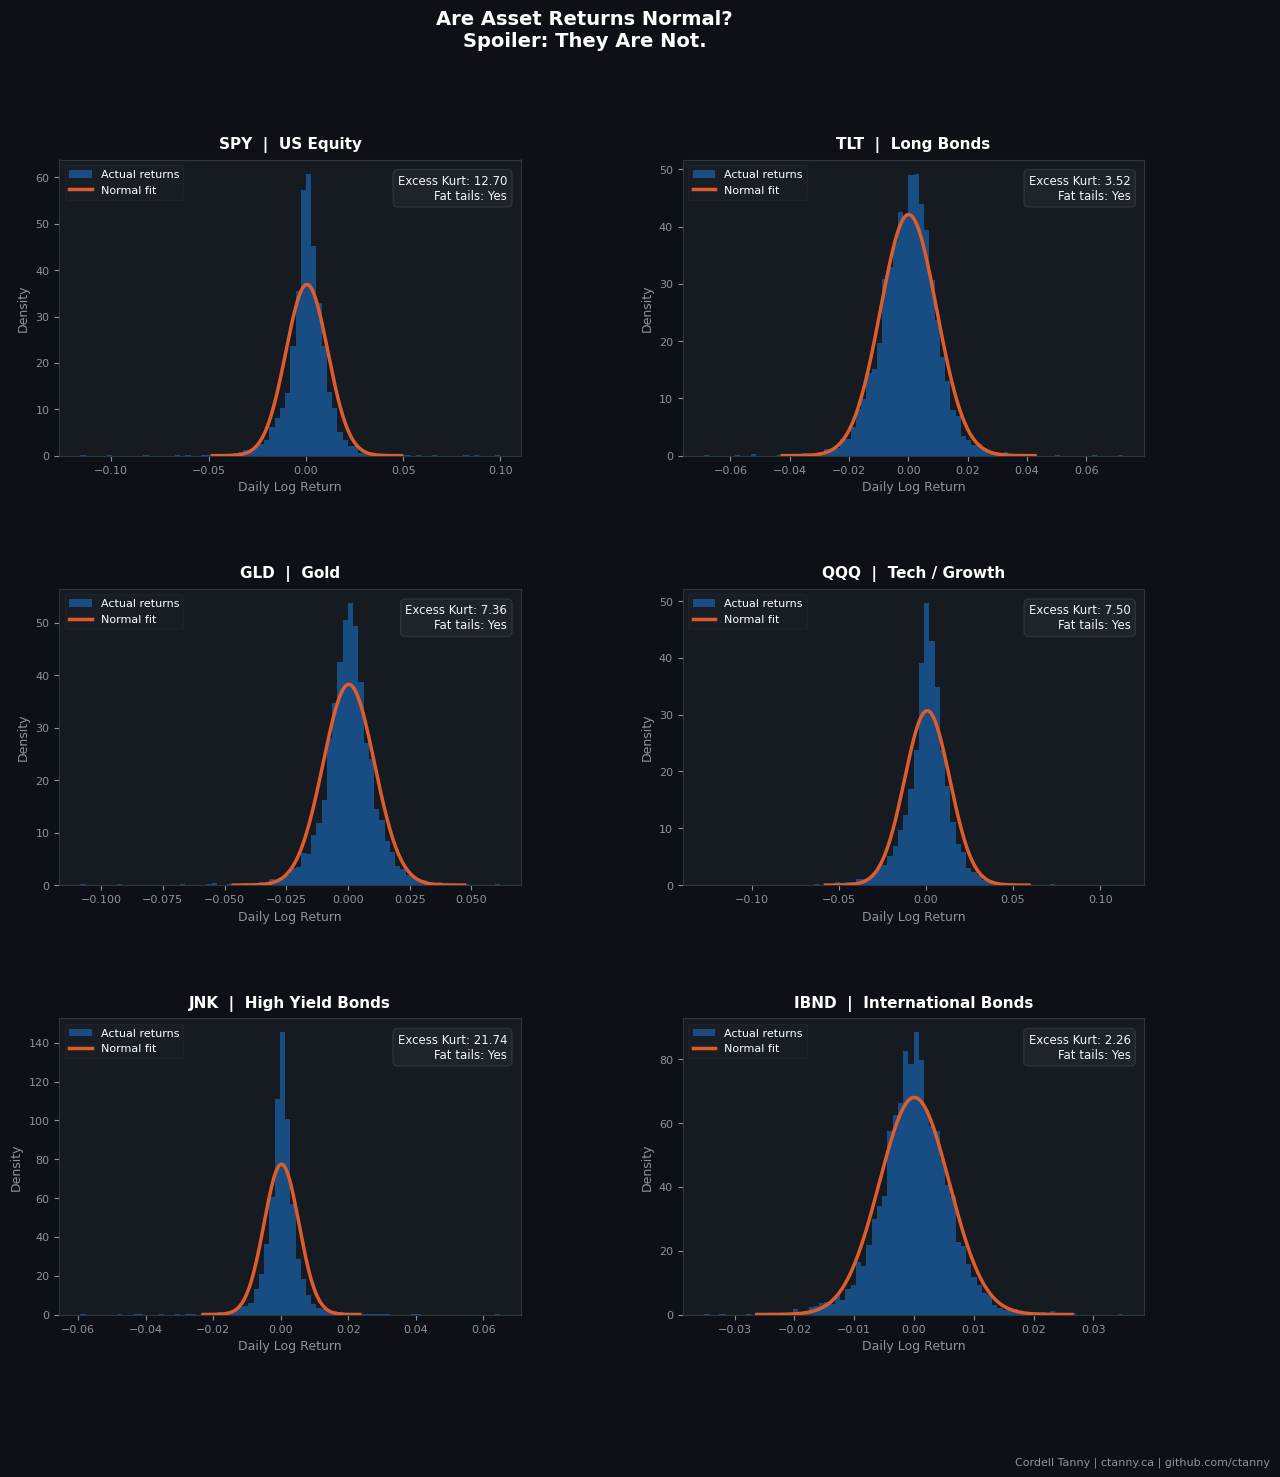

In [10]:
fig = plt.figure(figsize=(14, 15))
fig.patch.set_facecolor('#0d1117')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

for i, (ticker, label) in enumerate(tickers.items()):
    ax = fig.add_subplot(gs[i // 2, i % 2])
    ax.set_facecolor('#161b22')

    r        = returns[ticker].dropna()
    mu, sigma = r.mean(), r.std()
    kurt_val  = stats.kurtosis(r)

    # Actual return histogram
    ax.hist(r, bins=80, density=True, color='#185FA5',
            alpha=0.75, label='Actual returns', zorder=2)

    # Normal distribution overlay
    x = np.linspace(mu - 4.5*sigma, mu + 4.5*sigma, 300)
    ax.plot(x, stats.norm.pdf(x, mu, sigma),
            color='#E05C2A', linewidth=2.5, label='Normal fit', zorder=3)

    ax.set_title(f'{ticker}  |  {label}',
                 color='white', fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Daily Log Return', color='#8b949e', fontsize=9)
    ax.set_ylabel('Density',          color='#8b949e', fontsize=9)
    ax.tick_params(colors='#8b949e',  labelsize=8)
    for sp in ax.spines.values():
        sp.set_edgecolor('#30363d')

    ax.text(0.97, 0.95,
            f'Excess Kurt: {kurt_val:.2f}\nFat tails: Yes',
            transform=ax.transAxes, color='#f0f6fc', fontsize=8.5,
            ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#21262d',
                      edgecolor='#30363d', alpha=0.9))

    ax.legend(fontsize=8, framealpha=0.3, labelcolor='white',
              facecolor='#21262d', edgecolor='#30363d')

fig.suptitle('Are Asset Returns Normal?\nSpoiler: They Are Not.',
             color='white', fontsize=14, fontweight='bold', y=0.98)

plt.figtext(0.99, 0.01,
            'Cordell Tanny | ctanny.ca | github.com/ctanny',
            ha='right', color='#8b949e', fontsize=8)

plt.savefig('normality_tests.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 6. QQ Plots: Visualizing the Deviation from Normality

A QQ plot (quantile-quantile plot) compares the quantiles of your
actual return distribution against the quantiles of a theoretical
normal distribution.

If returns were perfectly normal, every point would fall exactly
on the red diagonal line.

What fat tails look like on a QQ plot:
- Points curve **above** the line in the upper right = right tail
  is heavier than normal
- Points curve **below** the line in the lower left = left tail
  is heavier than normal
- The more the points deviate from the line at the extremes,
  the fatter the tails

This S-curve pattern is the visual signature of leptokurtosis.
You will see it clearly in every asset below — especially JNK.

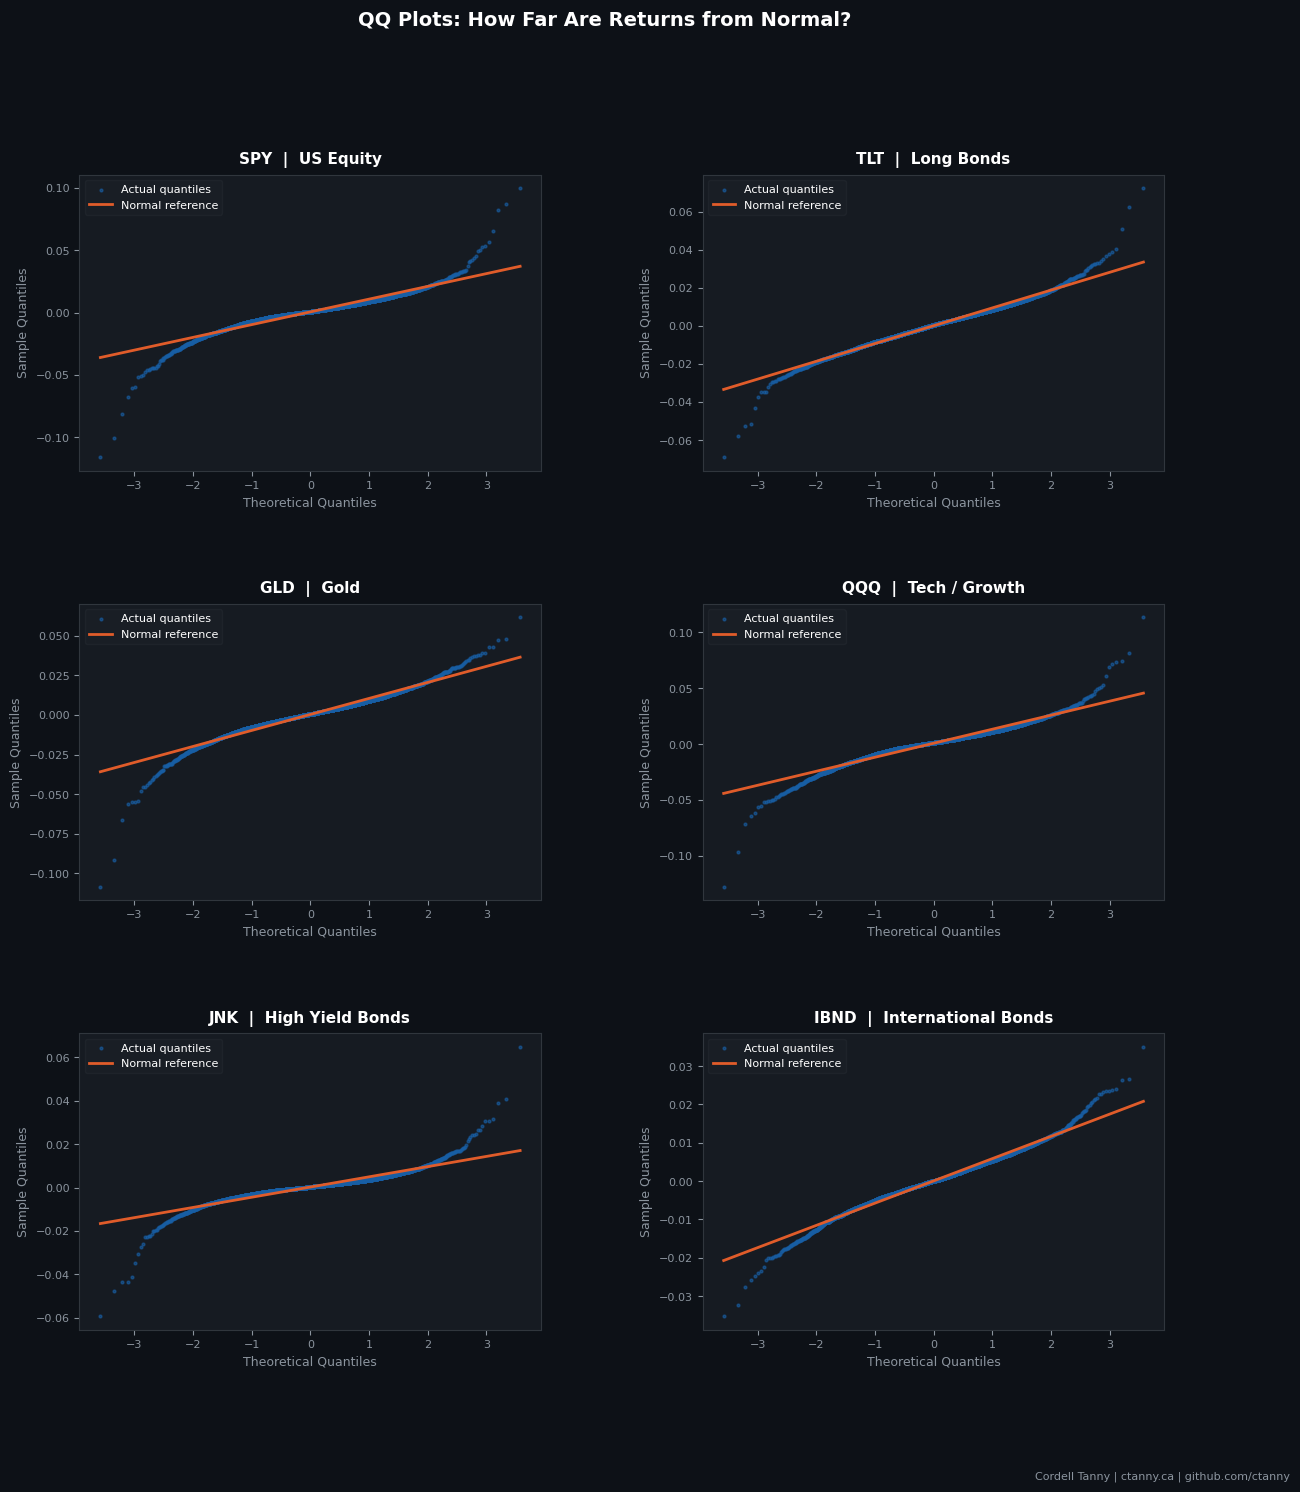

In [11]:
fig = plt.figure(figsize=(14, 15))
fig.patch.set_facecolor('#0d1117')
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

for i, (ticker, label) in enumerate(tickers.items()):
    ax = fig.add_subplot(gs[i // 2, i % 2])
    ax.set_facecolor('#161b22')

    r = returns[ticker].dropna()

    # Compute QQ plot values
    (osm, osr), (slope, intercept, r_sq) = stats.probplot(r, dist='norm')

    # Scatter: actual quantiles vs theoretical
    ax.scatter(osm, osr, color='#185FA5', s=4, alpha=0.6,
               label='Actual quantiles', zorder=2)

    # Reference line: perfect normality
    x_line = np.array([osm.min(), osm.max()])
    ax.plot(x_line, slope * x_line + intercept,
            color='#E05C2A', linewidth=2, label='Normal reference', zorder=3)

    ax.set_title(f'{ticker}  |  {label}',
                 color='white', fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Theoretical Quantiles', color='#8b949e', fontsize=9)
    ax.set_ylabel('Sample Quantiles',      color='#8b949e', fontsize=9)
    ax.tick_params(colors='#8b949e', labelsize=8)
    for sp in ax.spines.values():
        sp.set_edgecolor('#30363d')

    ax.legend(fontsize=8, framealpha=0.3, labelcolor='white',
              facecolor='#21262d', edgecolor='#30363d')

fig.suptitle('QQ Plots: How Far Are Returns from Normal?',
             color='white', fontsize=14, fontweight='bold', y=0.99)

plt.figtext(0.99, 0.01,
            'Cordell Tanny | ctanny.ca | github.com/ctanny',
            ha='right', color='#8b949e', fontsize=8)

plt.savefig('qq_plots.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

### Interpreting the QQ Plots

The pattern is the same across all six assets: points follow the
orange line through the middle, then peel away sharply at both ends.

That deviation at the extremes is the fat tail signature.
If returns were normal, every point would hug the line from
end to end.

A few things worth noting:

**SPY and QQQ** show the most dramatic curl at both ends.
Extreme up and down days happen far more often than the normal
distribution expects. Anyone who traded through 2008, 2020,
or the 2022 rate shock felt this firsthand.

**GLD** curls hard on the left tail only. Gold's extreme moves
tend to be to the downside — the right tail is surprisingly
better behaved.

**JNK** tells the clearest story. The left tail deviation is
severe. High yield bonds have a well-known pattern: calm and
stable for long stretches, then violent drawdowns when credit
spreads blow out. The QQ plot captures that asymmetry exactly.

**IBND** is the closest to normal of the six — the points stay
near the line longer before drifting. But they still drift.
Even the most "well-behaved" asset class in this group
rejects normality.

Bottom line: the histogram shows you the fat tails.
The QQ plot shows you exactly where they live.

## 7. Key Takeaways

1. **Every asset class rejected normality** — both tests, p-value effectively zero across the board.

2. **Fat tails are real and significant.** Excess kurtosis values well above zero mean extreme daily moves are far more common than a normal model would predict. This is not a minor rounding error — it is a structural feature of financial markets.

3. **Skewness varies by asset class.** Equities tend to show negative skew (crashes are sharper than rallies). Bonds and commodities can differ. The direction matters for risk management.

4. **Practical implications:**
   - Standard VaR (assuming normality) will **underestimate tail risk**
   - Sharpe ratio assumes normally distributed returns — use it, but know its limits
   - Backtests that assume normality for return generation will produce overly optimistic results
   - Consider fat-tailed alternatives: Student-t distributions, historical simulation, or extreme value theory for tail modeling

---

**What to read next:**
- If you want to model fat tails properly, look into **GARCH models** (upcoming notebook)
- For portfolio construction that accounts for non-normality, look into **CVaR optimization**

---

*Cordell Tanny, CFA, FRM, FDP*  
[ctanny.ca](https://ctanny.ca) | [github.com/ctanny](https://github.com/ctanny)  
*Questions or ideas? Connect on LinkedIn.*